<a href="https://colab.research.google.com/github/oxedanda/AVCAD/blob/main/Exercise_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import pandas as pd
import zipfile
import io

dataset_path = '/content/drive/MyDrive/Colab Notebooks/Exercicio_7/EFIplus_medit.zip'

try:
    with zipfile.ZipFile(dataset_path, 'r') as zf:
        csv_filename = zf.namelist()[0]
        with zf.open(csv_filename) as infile:
            csv_content = io.StringIO(infile.read().decode('utf-8'))
            df = pd.read_csv(csv_content, sep=';')

    print(f"Dataset loaded successfully from: {csv_filename} inside {dataset_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{dataset_path}' was not found. Please check the path.")
except IndexError:
    print(f"Error: No files found inside the zip archive '{dataset_path}'.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully from: EFIplus_medit.csv inside /content/drive/MyDrive/Colab Notebooks/Exercicio_7/EFIplus_medit.zip


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


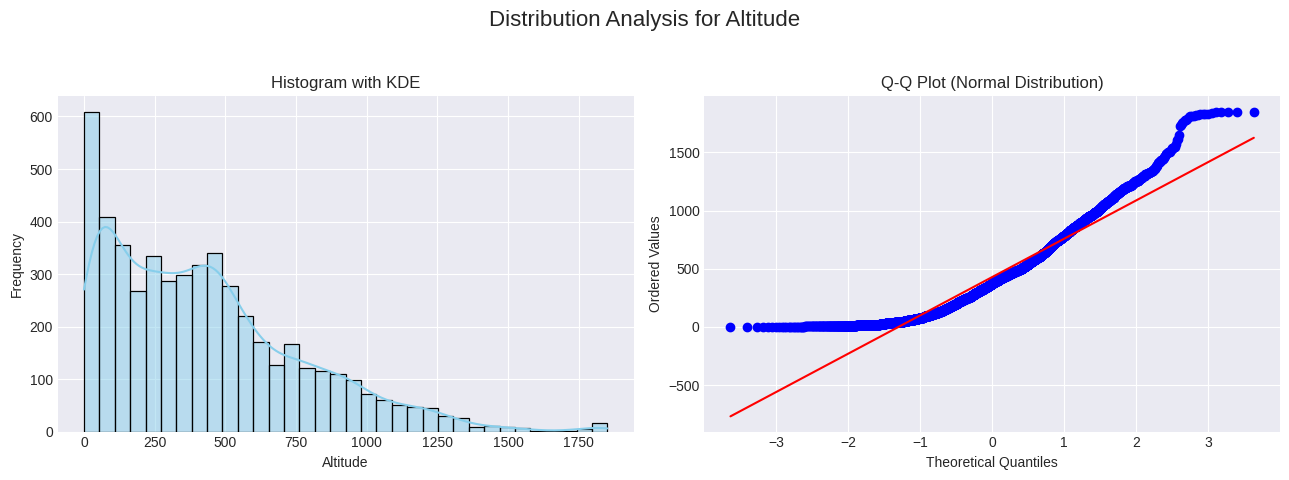

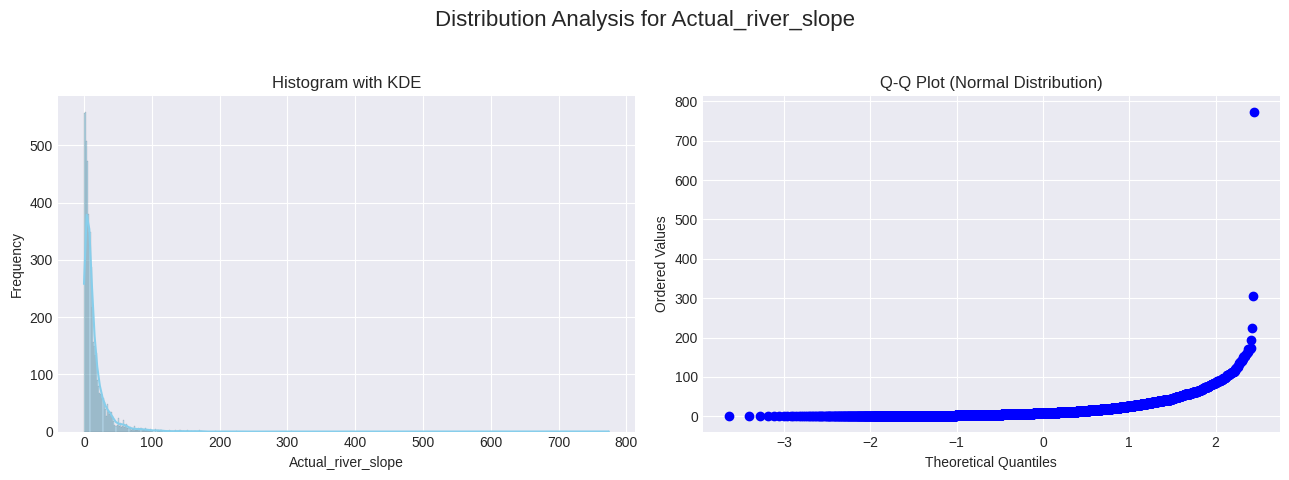

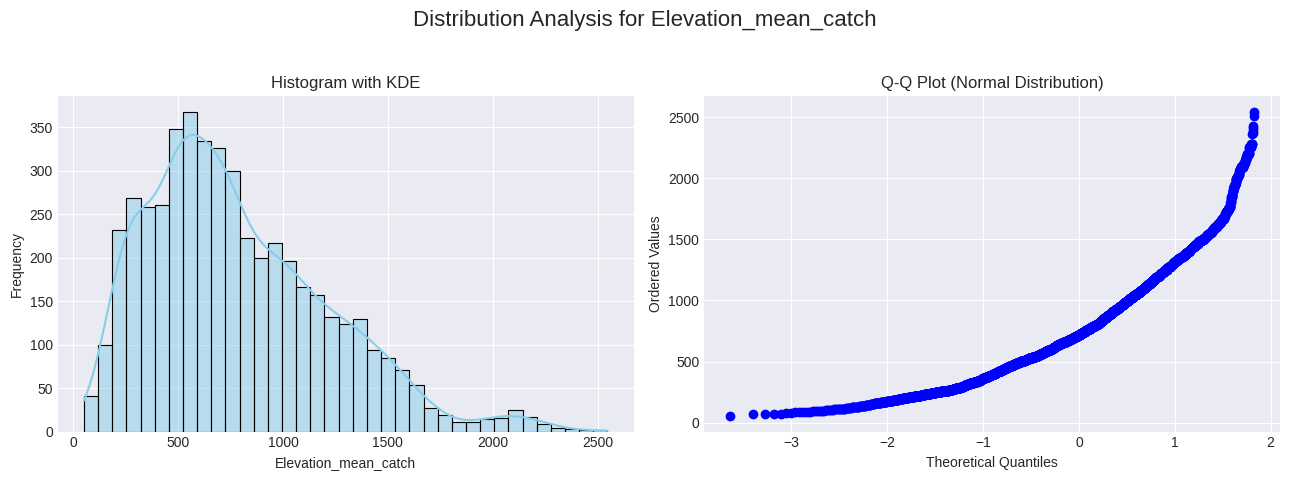

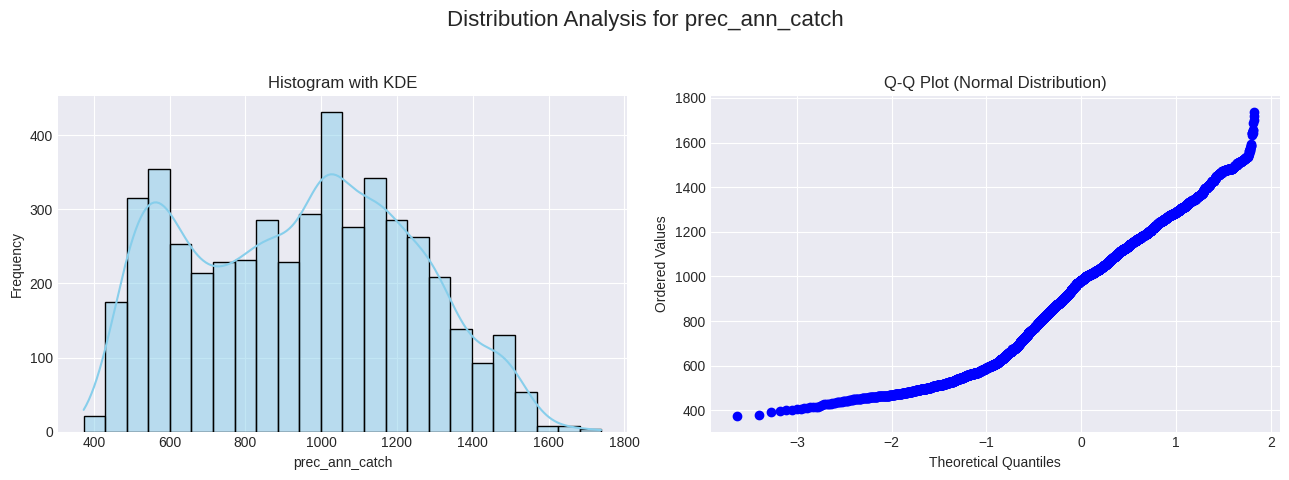

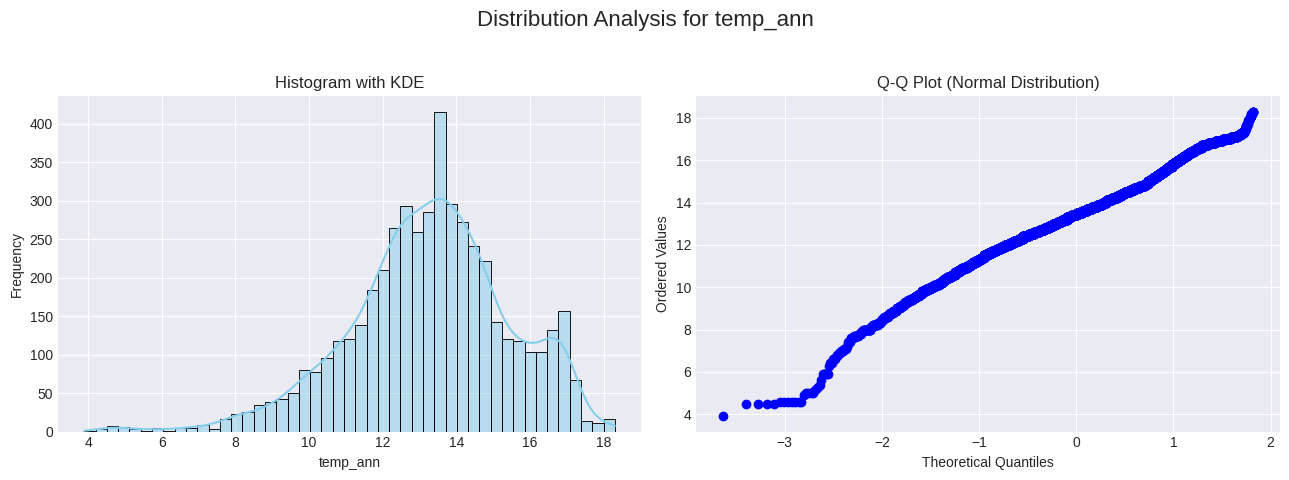

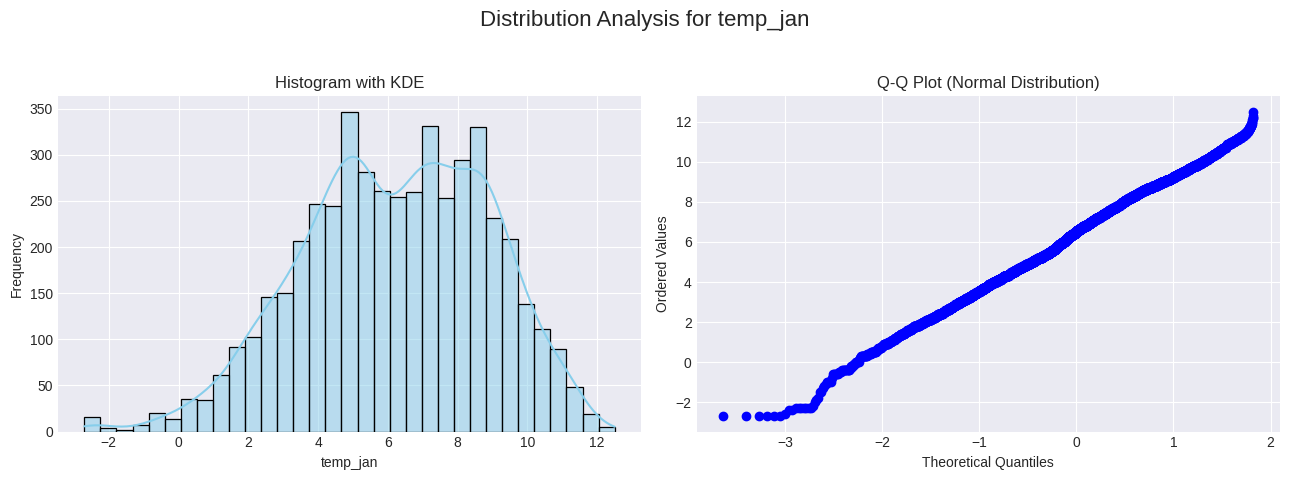

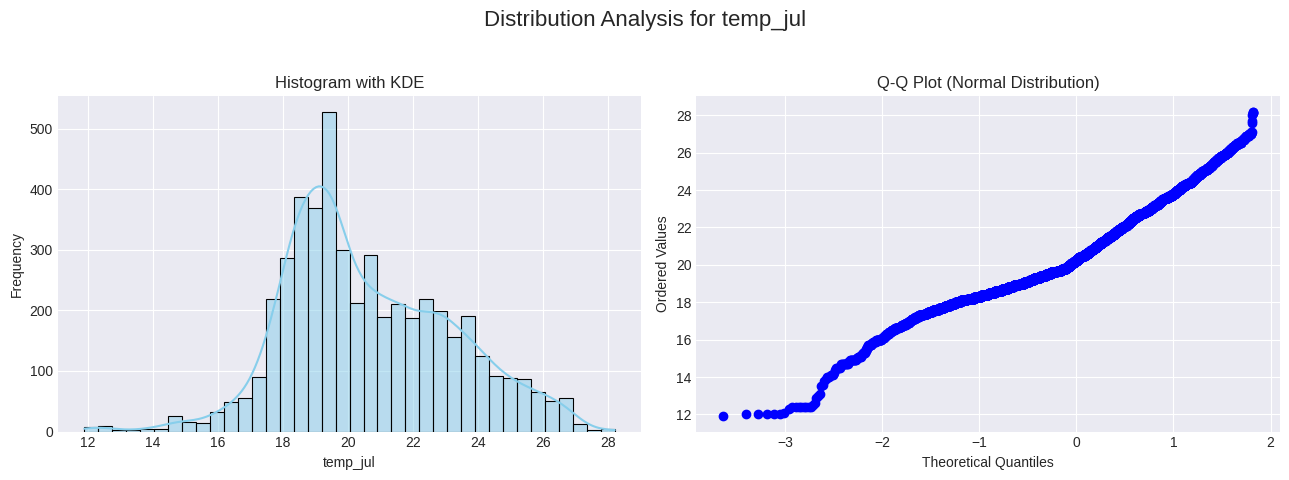

In [3]:
# 1.Check visually if any of the continuous environmental variables in the EFIplus_meditdataset
# (Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul)
# would require a data transformation in order to apply parametric tests.

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# List of variables to check
environmental_vars = [
    'Altitude', 'Actual_river_slope', 'Elevation_mean_catch',
    'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul'
]

plt.style.use('seaborn-v0_8-darkgrid')

for col in environmental_vars:
    if col in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(f'Distribution Analysis for {col}', fontsize=16)

        # Histogram
        sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title('Histogram with KDE')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frequency')

        # Q-Q Plot
        stats.probplot(df[col], dist="norm", plot=axes[1])
        axes[1].set_title('Q-Q Plot (Normal Distribution)')
        axes[1].set_xlabel('Theoretical Quantiles')
        axes[1].set_ylabel('Ordered Values')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print(f"Warning: Column '{col}' not found in the DataFrame.")

In [4]:
# 2. Apply the appropriate data transformation and check the new distributions.

import numpy as np

# Create a copy of the original DataFrame to store transformed data
df_transformed = df.copy()

#Based on these visual inspections, it was concluded that temp_jul likely did not require transformation
#because its distribution already appeared sufficiently close to a normal distribution.

# Variables identified for transformation
transformation_vars = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_jan'
]

# Apply square root transformation to the selected columns
for col in transformation_vars:
    if col in df_transformed.columns:
        # Ensure no negative values before applying sqrt, if temp_jan can be negative
        # For temp_jan, we will shift it to be non-negative first
        if col == 'temp_jan':
            min_val = df_transformed[col].min()
            if min_val < 0:
                # Shift values so the minimum becomes 0, then apply sqrt
                df_transformed[f'sqrt_{col}'] = np.sqrt(df_transformed[col] - min_val)
                print(f'Applied square root transformation with shift to: {col}')
            else:
                df_transformed[f'sqrt_{col}'] = np.sqrt(df_transformed[col])
                print(f'Applied square root transformation to: {col}')
        else:
            # For other variables, directly apply square root
            df_transformed[f'sqrt_{col}'] = np.sqrt(df_transformed[col])
            print(f'Applied square root transformation to: {col}')
    else:
        print(f"Warning: Column '{col}' not found for transformation.")

print('\nDisplaying head of df_transformed with new sqrt_ columns:')
display(df_transformed[[f'sqrt_{col}' for col in transformation_vars]].head())

Applied square root transformation to: Altitude
Applied square root transformation to: Actual_river_slope
Applied square root transformation to: Elevation_mean_catch
Applied square root transformation to: prec_ann_catch
Applied square root transformation with shift to: temp_jan

Displaying head of df_transformed with new sqrt_ columns:


,sqrt_Altitude,sqrt_Actual_river_slope,sqrt_Elevation_mean_catch,sqrt_prec_ann_catch,sqrt_temp_jan
0,14.106736,0.031623,26.473398,22.848877,3.346640
1,35.397740,3.661420,40.043969,25.304699,1.816590
2,33.985291,3.065616,39.732588,25.164237,1.974842
3,32.771939,2.861119,39.410901,25.016832,1.974842
4,31.906112,3.425785,39.238820,24.942161,2.097618


In [5]:
# 3. Create a column with the total number of species present (the species richness) in each sampling site
# (NOTE: the first species in the dataset is ‘Abramisbrama’ and all the columns to the right correspond to species presence/absence).

print("Available columns in df:")
print(df.columns.tolist())

# Correcting the column name to 'Abramis brama' based on the printed list
first_species_col_name = 'Abramis brama'

try:
    first_species_col_idx = df.columns.get_loc(first_species_col_name)

    # Select all species columns from the identified first species onwards
    species_cols = df.columns[first_species_col_idx:].tolist()

    # Calculate species richness by summing across the species columns for each row
    # Assuming presence/absence is represented by 0/1 or similar numeric values
    df['species_richness'] = df[species_cols].sum(axis=1)

    print(f"\nTotal number of species considered for richness calculation: {len(species_cols)} species.")
    print(f"DataFrame with 'species_richness' column added. This column sums the presence of {len(species_cols)} species starting from '{first_species_col_name}':")
    display(df[['Site_code', first_species_col_name, 'species_richness']].head())
except KeyError:
    print(f"\nError: The column '{first_species_col_name}' was not found. Please check the available columns above and specify the correct first species column name.")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")

Available columns in df:
['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eu

,Site_code,Abramis brama,species_richness
0,ES_01_0002,0,1
1,ES_02_0001,0,1
2,ES_02_0002,0,1
3,ES_02_0003,0,2
4,ES_02_0004,0,2


In [6]:
# Select a few representative species columns to display alongside species_richness
sample_species_cols = [
    'Abramis brama',
    'Achondrostoma arcasii',
    'Alburnus alburnus',
    'Anguilla anguilla'
]

# Ensure these columns exist before trying to display them
existing_sample_cols = [col for col in sample_species_cols if col in df.columns]

print("\nDisplaying 'species_richness' alongside a few sample species columns to illustrate the calculation:")
display(df[['Site_code'] + existing_sample_cols + ['species_richness']].head(10))


Displaying 'species_richness' alongside a few sample species columns to illustrate the calculation:


,Site_code,Abramis brama,Achondrostoma arcasii,Alburnus alburnus,Anguilla anguilla,species_richness
0,ES_01_0002,0,0,0,0,1
1,ES_02_0001,0,0,0,0,1
2,ES_02_0002,0,0,0,0,1
3,ES_02_0003,0,0,0,0,2
4,ES_02_0004,0,0,0,0,2
5,ES_02_0005,0,0,0,0,4
6,ES_02_0006,0,0,0,0,4
7,ES_02_0007,0,0,0,0,6
8,ES_02_0008,0,0,0,0,4
9,ES_02_0010,0,0,0,0,1


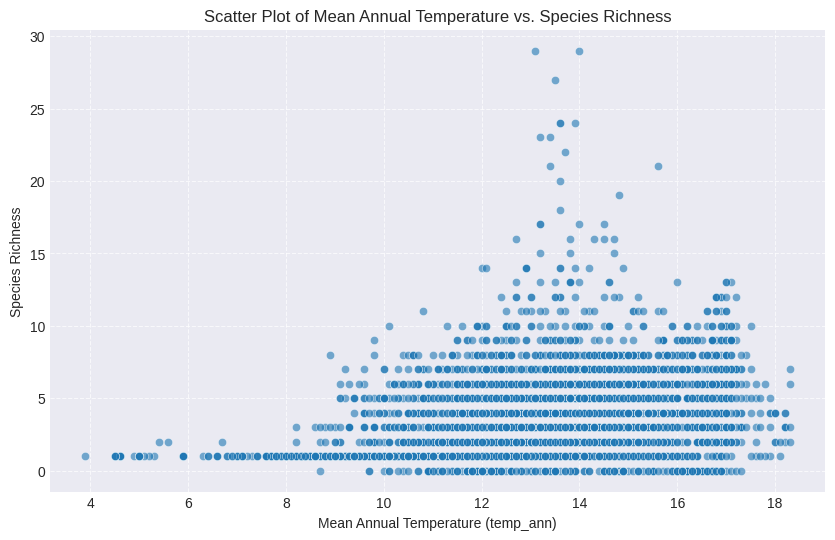

In [7]:
# 4. Check the existence of bivariate outliers in the relationship between Mean Annual Temperature (‘temp_ann’) and species richness using an appropriate plot.
#Run a bivariate isolation forest to detect outliers and plot the result.

import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temp_ann', y='species_richness', data=df, alpha=0.6)
plt.title('Scatter Plot of Mean Annual Temperature vs. Species Richness')
plt.xlabel('Mean Annual Temperature (temp_ann)')
plt.ylabel('Species Richness')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

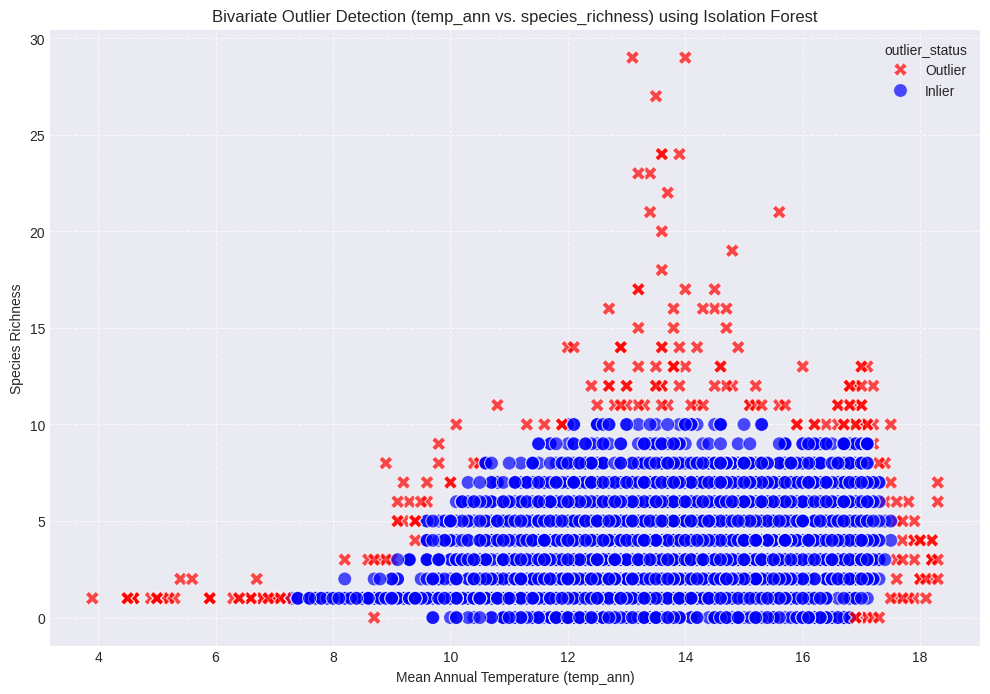

In [8]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Select the relevant columns for outlier detection
X = df[['temp_ann', 'species_richness']].copy()

# Handle potential NaN values (Isolation Forest cannot handle NaNs)
# For simplicity, we'll drop rows with NaNs in these columns.
# Alternatively, imputation could be used if data loss is a concern.
initial_rows = X.shape[0]
X.dropna(inplace=True)
if X.shape[0] < initial_rows:
    print(f"Warning: {initial_rows - X.shape[0]} rows dropped due to NaN values in 'temp_ann' or 'species_richness'.")

# Train the Isolation Forest model
# contamination is the proportion of outliers in the data set.
# Setting a contamination value is often based on domain knowledge or experimentation.
# Here, we assume a small percentage (e.g., 5%) of outliers.
model = IsolationForest(random_state=42, contamination=0.05, n_estimators=100, max_features=2)
model.fit(X)

# Predict outliers (-1 for outliers, 1 for inliers)
outlier_predictions = model.predict(X)

# Map numerical predictions to descriptive strings for better legend display
X['outlier_status'] = np.where(outlier_predictions == 1, 'Inlier', 'Outlier')

# Plot the results, highlighting outliers
plt.figure(figsize=(12, 8))
sns.scatterplot(x='temp_ann', y='species_richness', data=X,
                hue='outlier_status', palette={'Inlier': 'blue', 'Outlier': 'red'},
                style='outlier_status', markers={'Inlier': 'o', 'Outlier': 'X'},
                s=100, alpha=0.7)
plt.title('Bivariate Outlier Detection (temp_ann vs. species_richness) using Isolation Forest')
plt.xlabel('Mean Annual Temperature (temp_ann)')
plt.ylabel('Species Richness')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

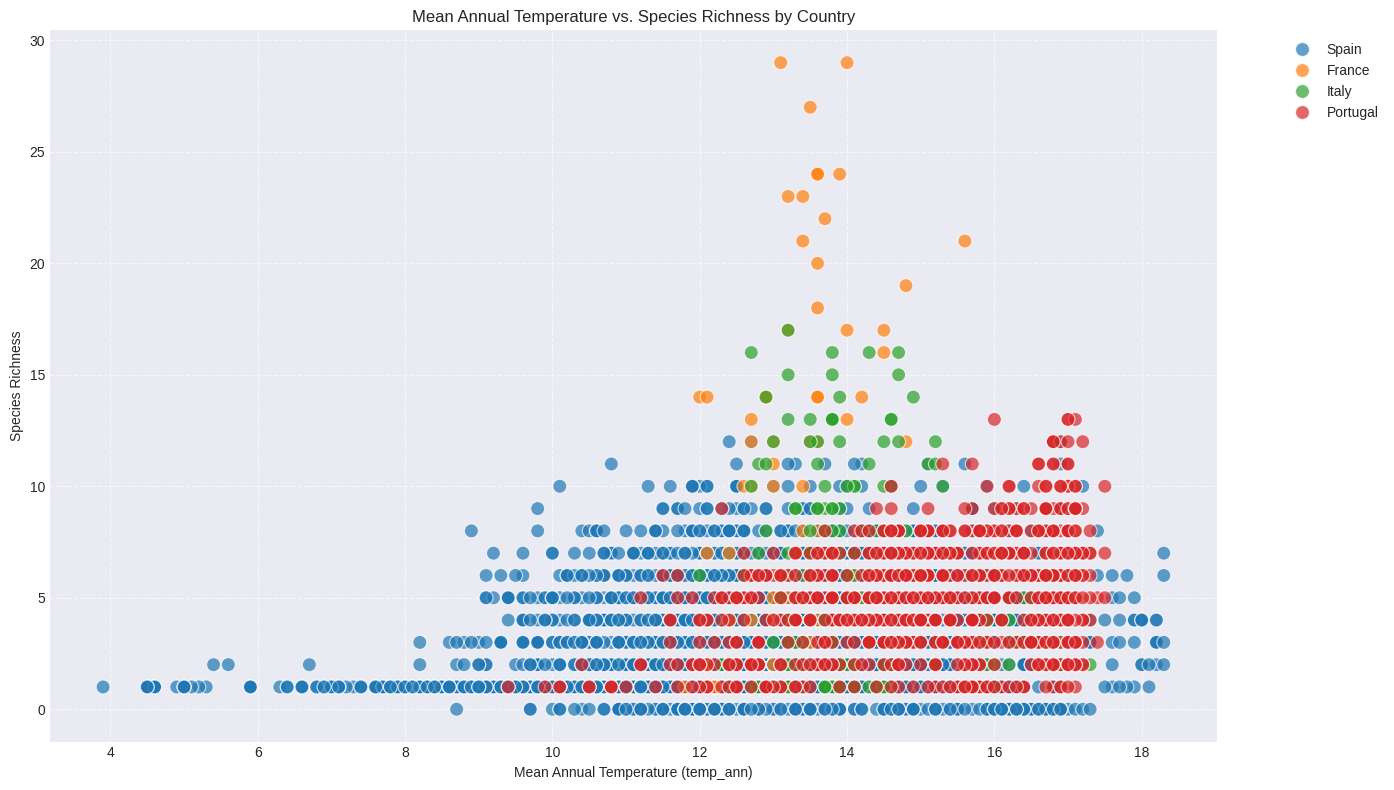

In [9]:
#5. Explore visually, using a single plot, if this relationship (temp_annx species richness) may vary across countries.

plt.figure(figsize=(14, 8))
sns.scatterplot(x='temp_ann', y='species_richness', hue='Country', data=df, alpha=0.7, s=100)
plt.title('Mean Annual Temperature vs. Species Richness by Country')
plt.xlabel('Mean Annual Temperature (temp_ann)')
plt.ylabel('Species Richness')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout()
plt.show()